In [27]:
!apt-get update -q
!apt-get install -y wget unzip -q

!wget -q -O chrome.deb https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!dpkg -i chrome.deb 2>/dev/null
!apt-get install -y -f -q
!pip install selenium webdriver-manager pandas matplotlib seaborn -q
print('Все ОК')

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Get:3 https://dl.google.com/linux/chrome-stable/deb stable InRelease [1,825 B]
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Get:9 https://dl.google.com/linux/chrome-stable/deb stable/main amd64 Packages [1,219 B]
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.2 MB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,020 kB]
Fetched 13.3 MB in 2s (6,917 kB/s)
Reading package lists...
W: Skipping

Using Colab cache for faster access to the 'realestaterent' dataset.
Количество объектов: 6898
Минимальная: 25,000 ₽/мес
Максимальная: 300,000 ₽/мес


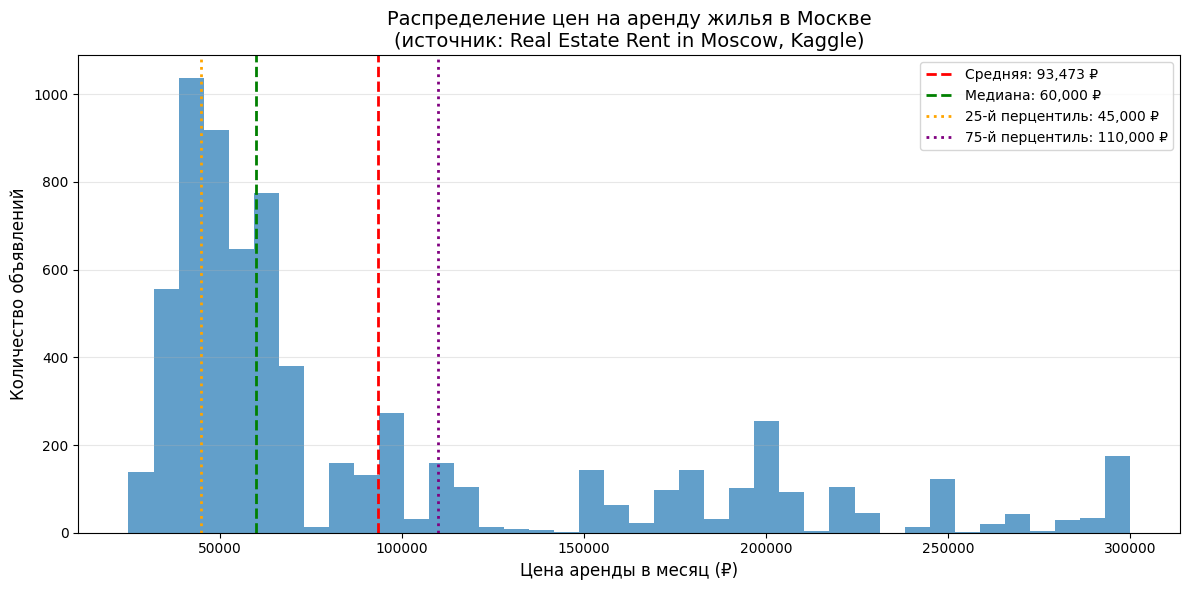

In [28]:
!pip install kagglehub pandas matplotlib -q

import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

path = kagglehub.dataset_download("timmofeyy/realestaterent")#скачала датасет с ценой аренды квартир в москве
csv_files = []
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.csv'):
            csv_files.append(os.path.join(root, file))

df = pd.read_csv(csv_files[0])
price_col = None
for col in df.columns:
    col_lower = col.lower()
    if 'price' in col_lower or 'rent' in col_lower or 'cost' in col_lower:
        price_col = col
        break

def clean_price(x):
    if pd.isna(x):
        return None
    if isinstance(x, (int, float)):
        return float(x)
    cleaned = re.sub(r'[^\d]', '', str(x))
    if cleaned:
        return float(cleaned)
    return None

import re
df['price_clean'] = df[price_col].apply(clean_price)
df = df.dropna(subset=['price_clean'])
df = df[(df['price_clean'] >= 5000) & (df['price_clean'] <= 300000)]
# Удаление выбросов
lower = df['price_clean'].quantile(0.01)
upper = df['price_clean'].quantile(0.99)
df_clean = df[(df['price_clean'] >= lower) & (df['price_clean'] <= upper)]

if len(df_clean) != 0:
    mean_price = df_clean['price_clean'].mean()
    median_price = df_clean['price_clean'].median()
    min_price = df_clean['price_clean'].min()
    max_price = df_clean['price_clean'].max()
    q25 = df_clean['price_clean'].quantile(0.25)
    q75 = df_clean['price_clean'].quantile(0.75)

    print(f"Количество объектов: {len(df_clean)}")
    print(f"Минимальная: {min_price:,.0f} ₽/мес")
    print(f"Максимальная: {max_price:,.0f} ₽/мес")


    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(df_clean['price_clean'], bins=40, alpha=0.7)
    ax.axvline(mean_price, color='red', linestyle='--', linewidth=2, label=f'Средняя: {mean_price:,.0f} ₽')
    ax.axvline(median_price, color='green', linestyle='--', linewidth=2, label=f'Медиана: {median_price:,.0f} ₽')
    ax.axvline(q25, color='orange', linestyle=':', linewidth=2, label=f'25-й перцентиль: {q25:,.0f} ₽')
    ax.axvline(q75, color='purple', linestyle=':', linewidth=2, label=f'75-й перцентиль: {q75:,.0f} ₽')
    ax.set_xlabel('Цена аренды в месяц (₽)', fontsize=12)
    ax.set_ylabel('Количество объявлений', fontsize=12)
    ax.set_title('Распределение цен на аренду жилья в Москве\n(источник: Real Estate Rent in Moscow, Kaggle)', fontsize=14)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('rent_distribution.png', dpi=100)
    plt.show()
    df_clean.to_csv('moscow_rent_clean.csv', index=False)

Медианная цена за м²: 1,190 ₽
Стоимость 30 м²: 35,714 ₽/мес
25%: 26,793 ₽/мес
75%: 52,287 ₽/мес


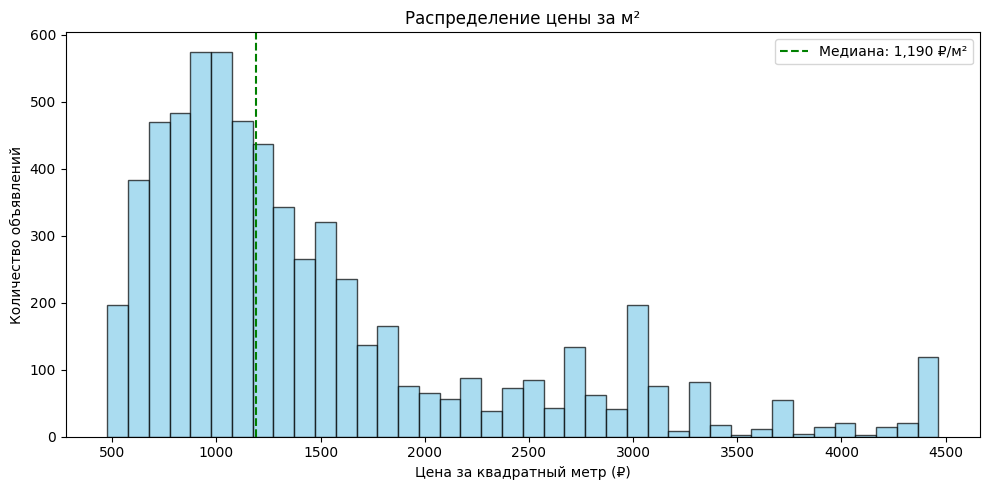


Среднеяя цена за проживание человека в 30ти метрах: 35,714 ₽/мес (норма 30 м²)


In [31]:

import pandas as pd
import matplotlib.pyplot as plt
import re

df = pd.read_csv('moscow_rent_clean.csv')

area_col = None
for col in df.columns:
    if 'total_area' in col.lower():
        area_col = col
        break
if area_col:
    def clean_area(x):
        if pd.isna(x):
            return None
        if isinstance(x, (int, float)):
            return x
        cleaned = re.sub(r'[^\d.]', '', str(x))
        return float(cleaned) if cleaned else None

    df['area_clean'] = df[area_col].apply(clean_area)
    df = df.dropna(subset=['area_clean'])
    df = df[(df['area_clean'] >= 10) & (df['area_clean'] <= 150)]

    #Считаю цену за м2 и убираю выбросы
    df['price_per_m2'] = df['price_clean'] / df['area_clean']
    lower = df['price_per_m2'].quantile(0.01)
    upper = df['price_per_m2'].quantile(0.99)
    df = df[(df['price_per_m2'] >= lower) & (df['price_per_m2'] <= upper)]

    median_m2 = df['price_per_m2'].median()
    cost_30m2 = median_m2 * 30 #30 - преполагаем такую площадь сиделке
    q25_m2 = df['price_per_m2'].quantile(0.25)
    q75_m2 = df['price_per_m2'].quantile(0.75)

    print(f"Медианная цена за м²: {median_m2:,.0f} ₽")
    print(f"Стоимость 30 м²: {cost_30m2:,.0f} ₽/мес")
    print(f"25%: {q25_m2 * 30:,.0f} ₽/мес")
    print(f"75%: {q75_m2 * 30:,.0f} ₽/мес")

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(df['price_per_m2'], bins=40, color='skyblue', edgecolor='black', alpha=0.7)
    ax.axvline(median_m2, color='green', linestyle='--', label=f'Медиана: {median_m2:,.0f} ₽/м²')
    ax.set_xlabel('Цена за квадратный метр (₽)')
    ax.set_ylabel('Количество объявлений')
    ax.set_title('Распределение цены за м²')
    ax.legend()
    plt.tight_layout()
    plt.savefig('price_per_m2.png', dpi=100)
    plt.show()

    print(f"\nСреднеяя цена за проживание человека в 30ти метрах: {cost_30m2:,.0f} ₽/мес (норма 30 м²)")